# Allen-Cahn PDE
## Experiments organization and dataset generation

### Experiments nomenclature

`L`[learning_mode]

- learning_mode $\in$ \{$w_1+...+w_k$ | \{$w_1, ..., w_k$\} $\in \mathcal{P}$(\{`pinn`, `out`, `der`, `hes`\})\}

### Experiments organization

**AllenCahn**

- **MultiTaskLearning** | **FullDomainLearning**
    - **Output** | **Derivative** | **Hesssian** | **PINN** | Mixed ...
        - **models0** | ... | **modelsM**
            - **tiral0** | ... | **trialN**
                - model.pth, training stats files
- **TaskIncrementalLearning** | **DomainIncrementalLearning**
    - **Output** | **Derivative** | **Hesssian** | **PINN** | Mixed ...
        - **Forget** | 
            - **FromScratch** | **FineTune** (*)
        - **Replay** | **Distill** | **Distill_EWC**
            - **Output** | **Derivative** | **Hesssian** | **PINN** | Mixed ...
                - **FromScratch** | **FineTune** (*)
        - **EWC**
            - **FromScratch** | **FineTune** (*)
    - **Task0** | **Dom0**
        - **models0** | ... | **modelsM**
            - **tiral0** | ... | **trialN**
                - model.pth, training stats files

(*):
- **Task1** | ... | **TaskT** | **Dom1** | ... | **DomD**
    - **models**
        - **trial0**
            - model.pth, training stats files

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, ConcatDataset
from generate import generate_from_config
from plot_utils import plot_points, plot_points_grid
from generate import X, U
from typing import Tuple, List
from data_utils import extract_targets
# ------------------------
SEED = 42
PDE = "AllenCahn"
PDE_NAME = "Allen-Cahn"

In [2]:
#def prepare_dataset(datasets: list, samples_per_dataset: int = -1, plot: bool = False, seed=42):
#    seeds = [seed+i for i in range(len(datasets))]
#    cols = None   
#    for ds, seed in zip(datasets, seeds):
#        torch.manual_seed(seed)
#        if samples_per_dataset != -1:
#            indices = torch.randperm(len(ds))[:samples_per_dataset]
#            if plot: plot_subsample(ds, indices)
#            new_cols = [col[indices] for col in ds.tensors]
#        else:
#            new_cols = list(ds.tensors)
#        if cols is None:
#            cols = new_cols
#        else:
#            for i, col in enumerate(new_cols):
#                cols[i] = torch.cat([cols[i], col])
#    return ConcatDataset([TensorDataset(*cols)])

### Functions to work with the A-C dataset

In [2]:
def subsample(
    datasets: List[ConcatDataset],
    n_dev_samples: int,
    n_test_samples: int,
    seed=42
    ) -> Tuple[List[ConcatDataset], List[ConcatDataset]]:

    dev_reduced_datasets = []
    test_reduced_datasets = []
    last_seed = seed
    for concat_ds in datasets:
        seeds = [last_seed+i for i in range(len(concat_ds))]
        last_seed = seeds[-1]
        dev_reduced_concat_ds = []
        test_reduced_concat_ds = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            dev_indices = indices[:n_dev_samples]
            test_indices = indices[n_dev_samples:n_dev_samples+n_test_samples]
            dev_reduced_cols = [col[dev_indices] for col in ds.tensors]
            dev_reduced_concat_ds.append(TensorDataset(*dev_reduced_cols))
            test_reduced_cols = [col[test_indices] for col in ds.tensors]
            test_reduced_concat_ds.append(TensorDataset(*test_reduced_cols))
        dev_reduced_datasets.append(ConcatDataset(dev_reduced_concat_ds))
        test_reduced_datasets.append(ConcatDataset(test_reduced_concat_ds))
    return dev_reduced_datasets, test_reduced_datasets

def split_train_val(
        dev_datasets: List[ConcatDataset],
        n_val_samples: int,
        seed: int = 42
        ) -> Tuple[List[ConcatDataset], List[ConcatDataset]]:
    
    val_datasets = []
    train_datasets = []
    for j, concat_ds in enumerate(dev_datasets):
        seeds = [seed+i*j for i in range(len(concat_ds))]
        train_concat_ds = []
        val_concat_ds = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            val_indices = indices[:n_val_samples]
            train_indices = indices[n_val_samples:]
            train_cols = [col[train_indices] for col in ds.tensors]
            train_concat_ds.append(TensorDataset(*train_cols))
            val_cols = [col[val_indices] for col in ds.tensors]
            val_concat_ds.append(TensorDataset(*val_cols))
        train_datasets.append(ConcatDataset(train_concat_ds))
        val_datasets.append(ConcatDataset(val_concat_ds))
    return train_datasets, val_datasets

def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset]) -> ConcatDataset:
    n_snapshots = len(datasets[0].datasets)
    data = [None for _ in range(n_snapshots)]
    for i in range(n_snapshots):
        data[i] = merge_ds([concat_ds.datasets[i] for concat_ds in datasets])
    return ConcatDataset(data)

### Data generation
- $\lambda = 0.01$
- 20 parameter vectors $\{\xi^i\}_i$,
- $\xi^i \in [-1, 1]^2$,
- $\xi^i \sim \mathcal{U}(-1, 1)$
- $(x, y) \in [-1, 1] \times [-1, 1]$
- $step = 0.02$ (both for the $x$ and $y$ dimentions)

In [ ]:
np.random.seed(SEED)

lam = 0.01

n_samples = 20
n_params = 2    # number of xi_j
a = -1.0        # min value for uniform sampling
b = 1.0         # max value for uniform sampling

# ~ Uniform [a, b]
xis = np.random.uniform(a, b, size=(n_samples, n_params))

ranges = {
    "x": [-1.0, 1.0],
    "y": [-1.0, 1.0]
    }
steps = {
    "dx": 0.02,
    "dy": 0.02
}
space = {"mode": "grid", "ranges": ranges, "steps": steps}

config_dict = {
    "PDE": PDE_NAME,
    "space": space,
    "seed": SEED
}

datasets = []
parameters = {"lam": lam}
for sample in xis:
    for i in range(n_params):
        parameters[f"xi{i+1}"] = sample[i]
    config_dict["parameters"] = parameters
    datasets.append(generate_from_config(config_dict))
print(xis)

# Save the datasets list as a ConcatDataset
os.makedirs(f"{PDE}/data", exist_ok=True)
os.makedirs(f"{PDE}/data/plots", exist_ok=True)
torch.save(ConcatDataset(datasets), f"{PDE}/data/full_datasets.pth")

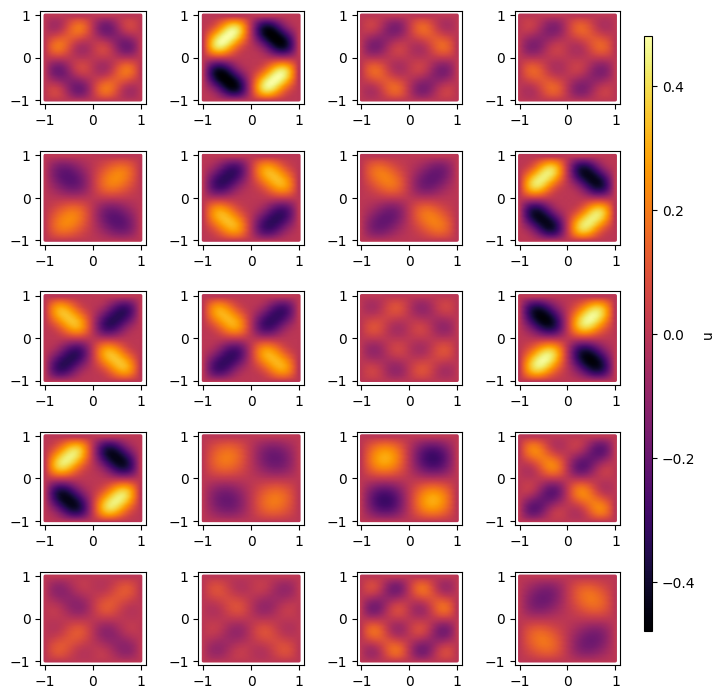

In [8]:
datasets = torch.load(f"{PDE}/data/full_datasets.pth", weights_only=False).datasets

# Plot
vmin = min([ds.datasets[0].tensors[U].min() for ds in datasets])
vmax = max([ds.datasets[0].tensors[U].max() for ds in datasets])

plot_points(
    dataset=[ds.datasets[0] for ds in datasets],
    points_idx=X,
    labels_idx=U,
    cmap="inferno",
    figsize=(8, 8.5),
    vmin=len(datasets)*[vmin],
    vmax=len(datasets)*[vmax],
    save=True,
    dst_file=f"{PDE}/data/plots/full_datasets2.png",
    show=True
)

In [14]:
x, u, ux, uy, uxx, uxy, uyx, uyy, res = 0, 1, 2, 3, 4, 5, 6, 7, 8
datasets_list = torch.load(f"{PDE}/data/full_datasets.pth", weights_only=False).datasets

targetss = []
vmins, vmaxs = [], []
for ds in datasets_list:
    targets = extract_targets(dataset=ds.datasets[0])
    targetss.append(targets)
    if vmins == []:
        for i in [u, ux, uy, uxx, uxy, uyx, uyy, res]:
            vmins.append(min(targets.tensors[i]))
            vmaxs.append(max(targets.tensors[i]))
    else:
        for i in [u, ux, uy, uxx, uxy, uyx, uyy, res]:
            vmins[i-1] = min(min(targets.tensors[i]), vmins[i-1])
            vmaxs[i-1] = max(max(targets.tensors[i]), vmaxs[i-1])

for i, targets in enumerate(targetss):
    plot_points_grid(
        dataset=targets,
        vmins=vmins,
        vmaxs=vmaxs,
        cmap="inferno",
        save=True,
        dst_file=f"{PDE}/data/plots/full_datasets_grid{i}.png",
        show=False
    );

vmins = np.array(vmins)
vmaxs = np.array(vmaxs)
np.save(f"{PDE}/data/vmins.npy", vmins)
np.save(f"{PDE}/data/vmaxs.npy", vmaxs)

In [ ]:
space["mode"] = "random_unlabeled"
space["n_rand"] = len(datasets[0])
config_dict["space"] = space
unlabeled_datasets = []
parameters = {"lam": lam}
for sample in xis:
    for i in range(n_params):
        parameters[f"xi{i+1}"] = sample[i]
    config_dict["parameters"] = parameters
    unlabeled_datasets.append(generate_from_config(config_dict))

# Save the datasets list as a ConcatDataset
os.makedirs(f"{PDE}/data", exist_ok=True)
os.makedirs(f"{PDE}/data/plots", exist_ok=True)
torch.save(ConcatDataset(unlabeled_datasets), f"{PDE}/data/unlabeled_datasets.pth")

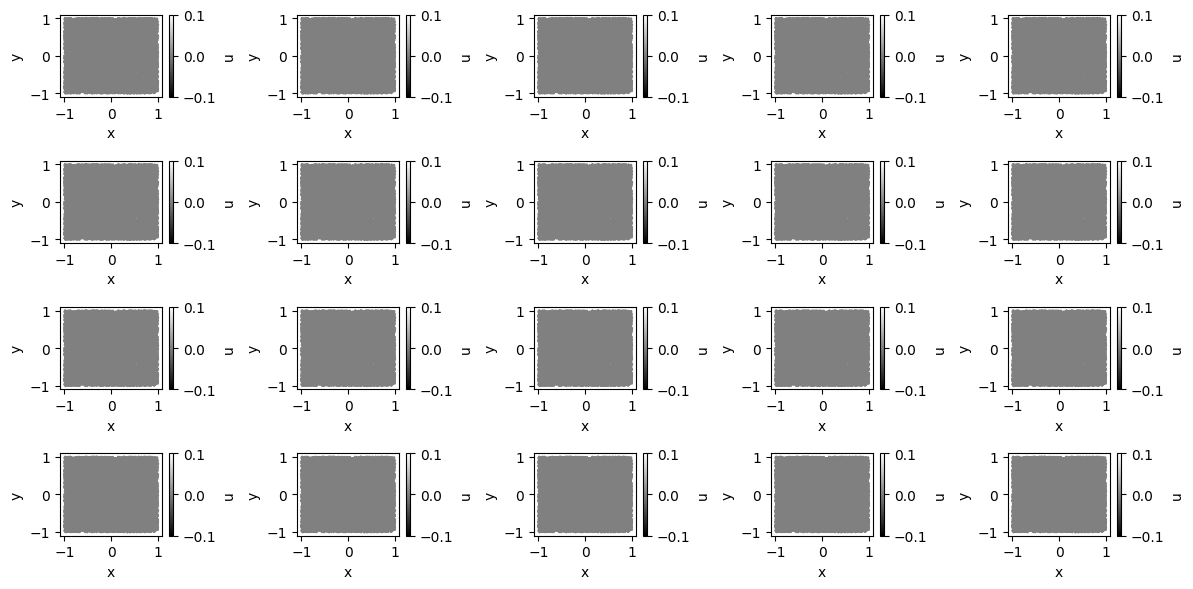

In [3]:
unlabeled_datasets = torch.load(f"{PDE}/data/unlabeled_datasets.pth", weights_only=False).datasets

# Plot
plot_points(
    dataset=[ds.datasets[0] for ds in unlabeled_datasets],
    points_idx=X,
    labels_idx=-1,
    cmap="Greys",
    figsize=(12, 6),
    save=True,
    dst_file=f"{PDE}/data/plots/unlabeled_datasets.png",
    show=True
)

### Tasks and evaluation
#### Task definition instantiation
A ***composed task*** or ***supertask*** is identified by a subset of parameter vectors ($\{\xi^0, ..., \xi^n\}$).

An ***atomic task*** or ***task*** is identified by a parameter vector ($\xi^i$).

Each composed task is disjoint from the others (i.e. the parameter vectors subset identifying any composed task has an empty intersection with the parameter vectors subset identifying any other different composed task).
#### Evaluation
- **Intra-task generalization**: Model's generalization capability w.r.t. unseen data inside the composed task (unseen coordinates, labeled according to a PDE with parameters inside a training task subset).
- **Inter-task generalization**: Model's generalization capability w.r.t. unseen tasks (parameter vectors/tasks not provided in training).

Then we need
- an intra-task validation(?) and test set and
- an inter-task validation(?) and test set.

(?) -> What to maintain? Which model to select?
- Keep the model with the best intra-task generalization.
- Keep the model with the best inter-task generalization.
- A combination (sum, weighted sum) of the two.
- Take the task parameter vectors, add *a little bit* of noise to them and select the best model on the noisy parameter vectors data. Note: This does not necessarily ensure a locality in the target function space (i.e. does not ensure that the noisy function is *similar* to the original one) in general, but likely, if the space is not *too irregular*.

In a Task Incremental Learning (TIL) application, the model selection is typically performed only at the first step. Then a validation set is needed only at the first step. It can be designed taking into account the intra-task or the inter-task generalizability or both.

In a TIL application there are two possible objectives:
- Maintain a model that performs well on the whole considered task space (all tasks are equally important at each step). In this case, an inter-task test set has to be
    - maintained (updated at each step, as new tasks arrives)
    - fixed at the beginning (if available, representative enough at the beginning),
in order to well represent the whole task space.
- Maintain a model that primarly performs well on the recent tasks and is updated in such a way to keep this property as new tasks arrive. In this case, an inter-task test sets have to be maintained (updated at each step, as new tasks arrives) to well represent the subset of tasks *close* to the current one. Extreme case: maintain only the current intra-task test set.

### Dataset splitting
|task| = $k$ points.

The dataset $D$ of $n$ tasks is splitted into
- $D^{inter}_{dev}$ of $n_{dev} = 0.8 n$ tasks, $N_{dev} = n_{dev} k$ points.
- $D^{inter}_{test}$ of $n_{test} = 0.2 n$ tasks, $N_{test} = n_{test} k$ points (needed in order to evaluate the inter-task generalization of the final model).

$D^{inter}_{dev}$ is splitted into
- $D_{dev}$ of $m_{dev} = 0.8 N_{dev}$ points,
- $D_{test}$ of $m_{test} = 0.2 N_{dev}$ points (needed in order to evaluate the intra-task generalization of the final model).

In MTL, $D_{dev}$ is splitted into
- $D_{train}$ of $m_{train} = 0.75 |D_{dev}|$ points, 
- $D_{val}$ of $m_{val} = 0.25 |D_{dev}|$ points (needed in order to select the final model),

In TIL,
- $D_{dev}$ is processed as $D^0_{dev}, \dots, D^T_{dev}$, where
    - $\forall i, j \in \{0, \dots, T\}, i \neq j. D^i_{dev} \cap D^j_{dev} = \emptyset$;
    - $\forall i \in \{0, \dots, T\}. |D^i_{dev}| = K \frac{n_{dev}}{T}$ (1 composed task = K atomic tasks);
    - $D^0_{dev}$ is splitted into
        - $D^0_{train}$ of $0.75 |D^0_{dev}|$,
        - $D^0_{val}$ of $0.25 |D^0_{dev}|$ (needed in order to select the $0^{th}$ model);
    - $\forall i \in \{1, \dots, T\}. D^i_{dev}$ is $D^i_{train}$;

- $D_{test}$ is processed as $D^0_{test}, \dots, D^T_{test}$, where
    - $\forall i \in \{0, \dots, T\}. D^i_{test}$ needed in order to evaluate the intra-task generalization of the $i^{th}$, $(i+1)^{th}$, ..., $T^{th}$ models;
    
- $\bigcup_i D^i_{train}$ and $\bigcup_i D^i_{test}$ can be used to measure the (train and test) forgetting and transfer.

**Note**: In order to perform a comparison that is as fair as possible, $D_{test} = \bigcup_i D^i_{test}$.


#### Instantiations and subsampling
- $|task| = 3500$ points
- $n_{tasks} = 20$
- $|supertask| = 3 \times 3500 = 10500$ (1 supertask = 3 tasks)
- $|D^{full}| = 3500 \times 20 = 70000$
    - $|D| = |\bigcup_i D^i| = 16 \times 3500 = 56000$
    - $|InterTaskTest| = 4 \times 3500 = 14000$
- $|D^i| = 3 \times 3500 = 10500$
    - $|D^i_{dev}| = 3 \times 2100 = 6300$
    - $|D^i_{test}| = 3 \times 700 = 2100$
- $|D^0_{dev}|$:
    - $|D^0_{train}| = 3 \times 1400 = 4200$
    - $|D^0_{val}| = 3 \times 700 = 2100$
- $|D^i_{dev}|$, $i \geq 1$
    - $|D^i_{train}| = 6300$
- $|D| = |\bigcup_i D^i|$
    - $|D_{test}| = |\bigcup_i D^i_{test}| = 16 \times 700 = 11200$
    - $|D_{dev}| = |D \setminus D_{test}| = 56000 - 11200 = 44800$
        - $|D_{train}| = 0.8 \times 44800 = 35840$
        - $|D_{val}| = 0.2 \times 44800 = 8960$

In [ ]:
## |task| = 3500
## 60-20-20 split
#n_dev_points = 2100
#n_intra_test_points = 700
#n_val_points = 700

# |task| = 6144
#n_dev_points = 4096
#n_intra_test_points = 1024
#n_val_points = 1024

# |task| = 2560
n_dev_points = 2048
n_intra_test_points = 512
n_val_points = 512

dev_datasets, intra_test_datasets = subsample(
    datasets,
    n_dev_points,
    n_intra_test_points,
    seed=SEED
    )

train_datasets, val_datasets = split_train_val(
    dev_datasets,
    n_val_points,
    seed=SEED
)

print(f"|dev| = {len(dev_datasets[0])}")
print(f"|train| = {len(train_datasets[0])}")
print(f"|val| = {len(val_datasets[0])}")
print(f"|intra_test| = {len(intra_test_datasets[0])}")

n_tasks = len(train_datasets) # number of tasks
n_test_tasks = int(0.2 * n_tasks)
n_train_tasks = n_tasks - n_test_tasks

inter_test_datasets = dev_datasets[n_train_tasks:]
dev_datasets = dev_datasets[:n_train_tasks]
train_datasets = train_datasets[:n_train_tasks]
val_datasets = val_datasets[:n_train_tasks]
intra_test_datasets = intra_test_datasets[:n_train_tasks]

# Save the (dev_, train_, val_, intra_test_, inter_test_)datasets lists as ConcatDataset objects
torch.save(ConcatDataset(dev_datasets), f"{PDE}/data/dev_datasets.pth")
torch.save(ConcatDataset(train_datasets), f"{PDE}/data/train_datasets.pth")
torch.save(ConcatDataset(val_datasets), f"{PDE}/data/val_datasets.pth")
torch.save(ConcatDataset(intra_test_datasets), f"{PDE}/data/intra_test_datasets.pth")
torch.save(ConcatDataset(inter_test_datasets), f"{PDE}/data/inter_test_datasets.pth")
    
train_data = prepare_dataset(train_datasets)
val_data = prepare_dataset(val_datasets)
inter_test_data = prepare_dataset(inter_test_datasets)
intra_test_data = prepare_dataset(intra_test_datasets)

print(f"n_train_tasks: {n_train_tasks}\nn_inter_test_tasks: {n_test_tasks}")

--------------------------------- Dev set ---------------------------------


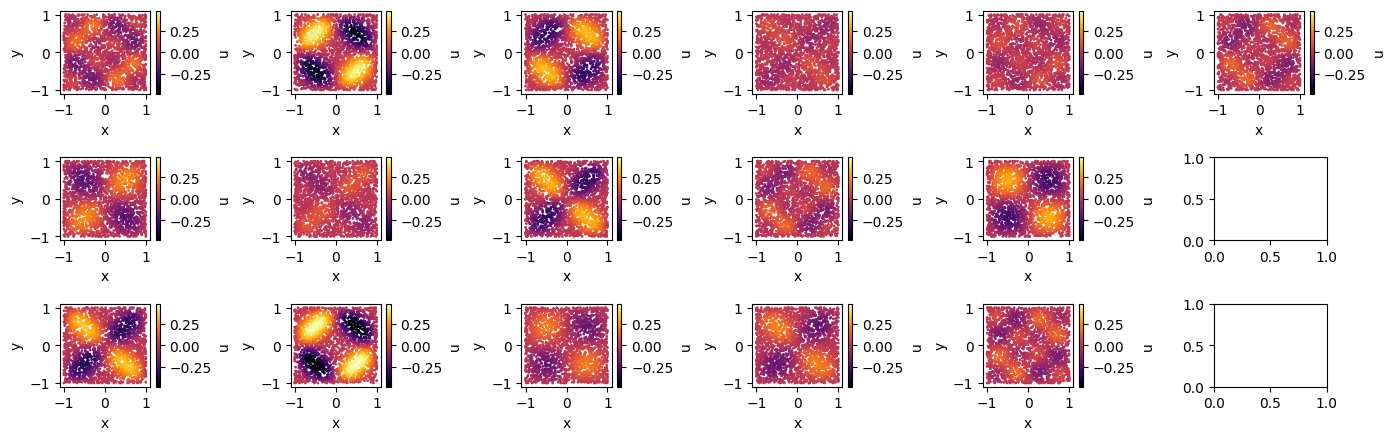

--------------------------------- Inter test set ---------------------------------


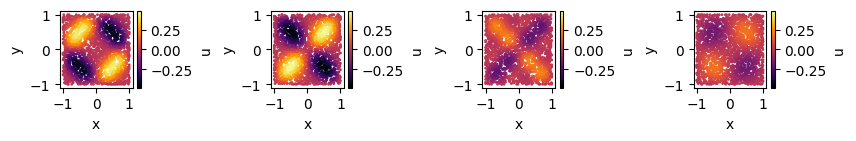

--------------------------------- Train set ---------------------------------


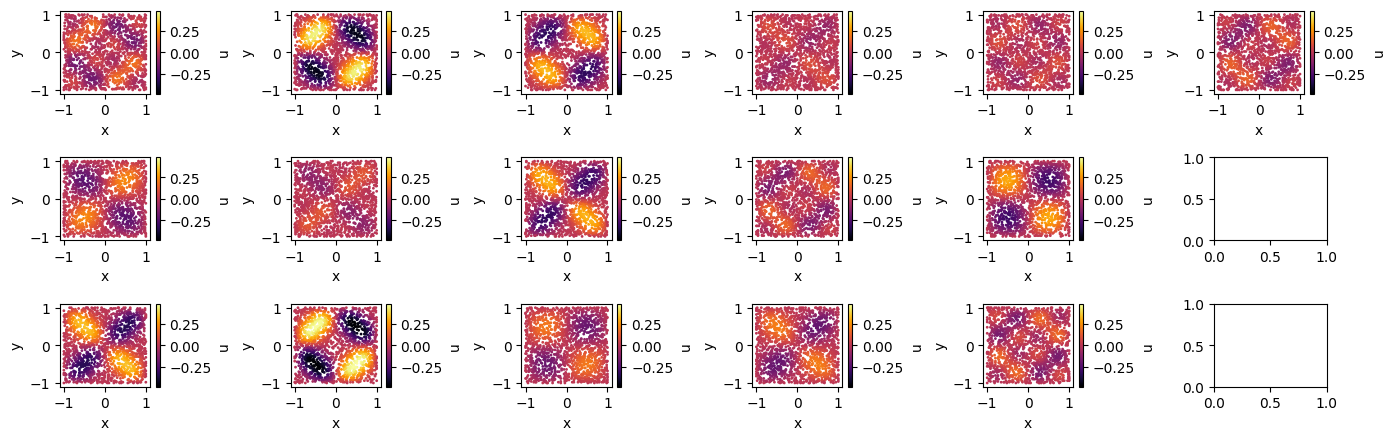

--------------------------------- Val set ---------------------------------


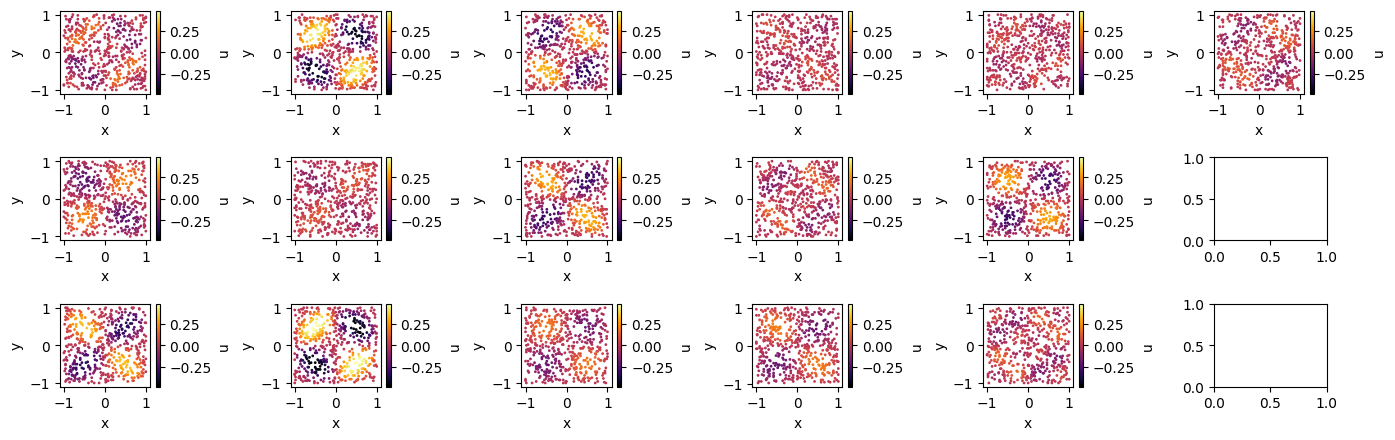

--------------------------------- Intra test set ---------------------------------


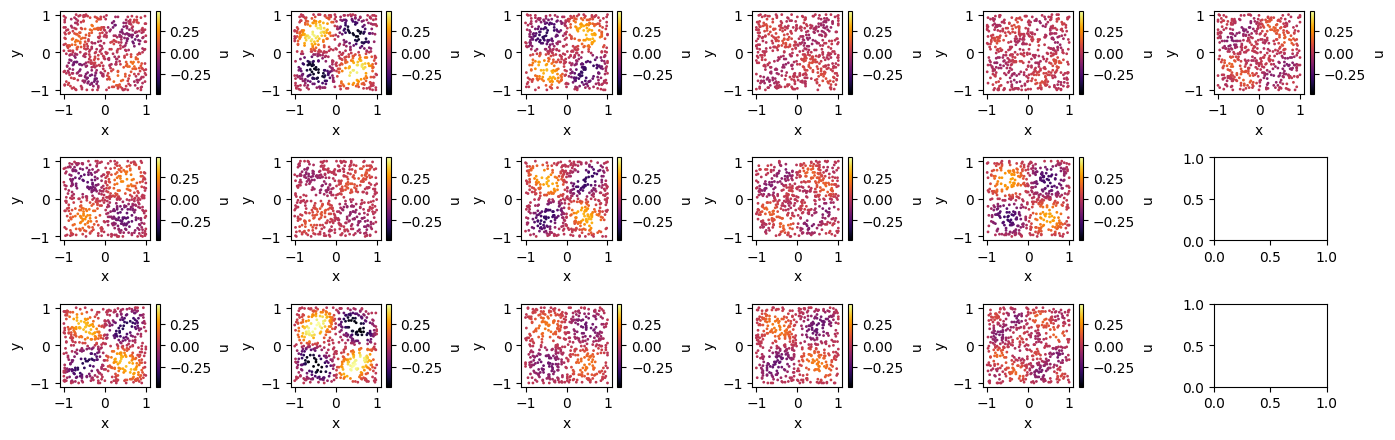

In [3]:
dev_datasets = torch.load(f"{PDE}/data/dev_datasets.pth", weights_only=False).datasets
train_datasets = torch.load(f"{PDE}/data/train_datasets.pth", weights_only=False).datasets
val_datasets = torch.load(f"{PDE}/data/val_datasets.pth", weights_only=False).datasets
intra_test_datasets = torch.load(f"{PDE}/data/intra_test_datasets.pth", weights_only=False).datasets
inter_test_datasets = torch.load(f"{PDE}/data/inter_test_datasets.pth", weights_only=False).datasets
full_datasets = torch.load(f"{PDE}/data/full_datasets.pth", weights_only=False).datasets

vmin = min([ds.datasets[0].tensors[U].min() for ds in full_datasets])
vmax = max([ds.datasets[0].tensors[U].max() for ds in full_datasets])

# Plot
for x_datasets, string, file_prefix, show, figsize in [
        (dev_datasets, "Dev set", "dev_datasets", True, (14, 4.5)),
        (inter_test_datasets, "Inter test set", "inter_test_datasets", True, (8.6, 1.5)),
        (train_datasets, "Train set", "train_datasets", True,(14, 4.5)),
        (val_datasets, "Val set", "val_datasets", True, (14, 4.5)),
        (intra_test_datasets, "Intra test set", "intra_test_datasets", True, (14, 4.5)),
    ]:
    if show:
        print(f"--------------------------------- {string} ---------------------------------")
    plot_points(
        dataset=[ds.datasets[0] for ds in x_datasets],
        points_idx=X,
        labels_idx=U,
        cmap="inferno",
        figsize=figsize,
        vmin=len(x_datasets)*[vmin],
        vmax=len(x_datasets)*[vmax],
        save=True,
        dst_file=f"{PDE}/data/plots/{file_prefix}.png",
        show=show
    )

In [7]:
from data_utils import extract_boundary, extract_interior
for ds in train_datasets:
    print((len(extract_boundary(ds)), len(extract_interior(ds))))

(56, 1481)
(83, 1454)
(58, 1479)
(74, 1462)
(51, 1485)
(47, 1489)
(62, 1475)
(48, 1488)
(54, 1482)
(50, 1486)
(55, 1481)
(70, 1466)
(66, 1470)
(58, 1478)
(67, 1472)
(63, 1473)


In [8]:
#n = len(datasets)
#n_val = int(0.2 * n)
#n_test = int(0.2 * n)
#n_train = n - n_val - n_test
#n_samples = 1000
#seed = 42
#
#snapshot_size = len(datasets[0].datasets[0])
#
#seed_train = seed
#seed_val = seed_train + n_train * snapshot_size
#seed_test = seed_val + n_val * snapshot_size
#seed_nl = seed_test + n_test * snapshot_size
#
#train_datasets = [ds.datasets[0] for ds in datasets[:n_train]]
#val_datasets = [ds.datasets[0] for ds in datasets[n_train:(n_train+n_val)]]
#test_datasets = [ds.datasets[0] for ds in datasets[n_train+n_val:]]
#
#train_data = prepare_dataset(train_datasets, n_samples, seed=seed_train, plot=False)
#val_data = prepare_dataset(val_datasets, n_samples, seed=seed_val, plot=False)
#test_data = prepare_dataset(test_datasets, n_samples, seed=seed_test, plot=False)
#
#print(f"n_train: {n_train}\nn_val: {n_val}\nn_test: {n_test}\nn_nl: {n_train}")